<a href="https://colab.research.google.com/github/Dele0-code/patient-monitor-app/blob/main/ECG_training_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install wfdb torch torchvision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 108.5 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.


In [8]:
!pip install scikit-learn

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# 1. Define the 1D-CNN Architecture
class ECGClassifier(nn.Module):
    def __init__(self):
        super(ECGClassifier, self).__init__()
        # First convolutional layer (looks for small local patterns)
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5, padding=2)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        # Second convolutional layer (combines patterns into larger shapes)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5, padding=2)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2)

        # Fully connected layers (makes the final decision)
        # Note: 32 channels * 25 length assumes an input window of 100 samples (1 second at 100Hz)
        self.fc1 = nn.Linear(32 * 25, 64)
        self.fc2 = nn.Linear(64, 2) # 2 Outputs: Normal (0) or Anomaly (1)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(x.size(0), -1) # Flatten the array
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialize the model, loss function, and optimizer
model = ECGClassifier().cuda() # Move to GPU
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --- PSEUDOCODE FOR TRAINING LOOP ---
# In reality, you will load the MIT-BIH dataset, resample it to 100Hz, and feed it here.
# For demonstration, we assume `train_loader` contains your formatted data batches.
'''
epochs = 10
for epoch in range(epochs):
    for ecg_signals, labels in train_loader:
        ecg_signals, labels = ecg_signals.cuda(), labels.cuda()

        optimizer.zero_grad()
        outputs = model(ecg_signals)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}/{epochs} completed.")

# Save the trained brain!
torch.save(model.state_dict(), 'ecg_model_100hz.pt')
'''

'\nepochs = 10\nfor epoch in range(epochs):\n    for ecg_signals, labels in train_loader:\n        ecg_signals, labels = ecg_signals.cuda(), labels.cuda()\n        \n        optimizer.zero_grad()\n        outputs = model(ecg_signals)\n        loss = criterion(outputs, labels)\n        loss.backward()\n        optimizer.step()\n        \n    print(f"Epoch {epoch+1}/{epochs} completed.")\n\n# Save the trained brain!\ntorch.save(model.state_dict(), \'ecg_model_100hz.pt\')\n'

In [3]:
!pip install wfdb scipy matplotlib

Generating record list for: 100
Generating list of all files for: 100
Finished downloading files
Original Signal Length: 650000 samples at 360Hz
Resampling to 100Hz...
New Signal Length: 180555 samples at 100Hz


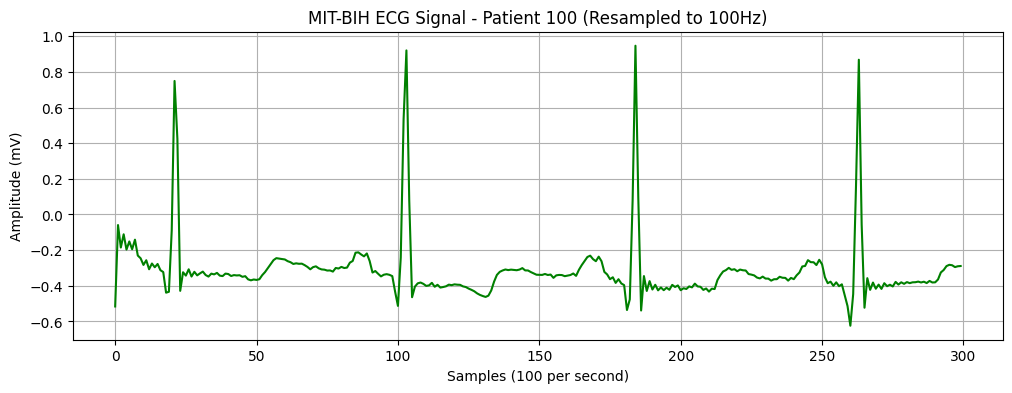

In [4]:
import os
import wfdb
import numpy as np
from scipy.signal import resample
import matplotlib.pyplot as plt

# 1. Create a folder to store the downloaded data
data_dir = 'mitdb_data'
if not os.path.exists(data_dir):
    os.makedirs(data_dir)

print("Downloading Patient 100 record from PhysioNet...")
# We specify just one record for testing.
# To download the whole database later, just remove the `records=['100']` argument.
wfdb.dl_database('mitdb', dl_dir=data_dir, records=['100'], annotators=['atr'])

# 2. Read the record and the annotations (labels)
record = wfdb.rdrecord(f'{data_dir}/100')
annotation = wfdb.rdann(f'{data_dir}/100', 'atr')

# Extract the raw ECG signal (Channel 0 is usually MLII, which is very similar to your Lead I)
raw_signal = record.p_signal[:, 0]
original_fs = record.fs # The MIT-BIH database is sampled at 360 Hz

print(f"Original Signal Length: {len(raw_signal)} samples at {original_fs}Hz")

# 3. Downsample the signal from 360Hz to 100Hz (Your ESP32 Speed)
target_fs = 100
# Calculate the total number of samples needed for the new frequency
num_samples = int(len(raw_signal) * (target_fs / original_fs))

print("Resampling to 100Hz...")
resampled_signal = resample(raw_signal, num_samples)
print(f"New Signal Length: {len(resampled_signal)} samples at {target_fs}Hz")

# 4. Plot the first 3 seconds of the resampled data to verify
plt.figure(figsize=(12, 4))
# 3 seconds at 100Hz = 300 samples
plt.plot(resampled_signal[:300], color='green')
plt.title("MIT-BIH ECG Signal - Patient 100 (Resampled to 100Hz)")
plt.xlabel("Samples (100 per second)")
plt.ylabel("Amplitude (mV)")
plt.grid(True)
plt.show()

Splitting continuous wave into individual heartbeats...
Total processed heartbeats extracted: 2271
Normal beats (Class 0): 2237
Abnormal/Arrhythmia beats (Class 1): 34


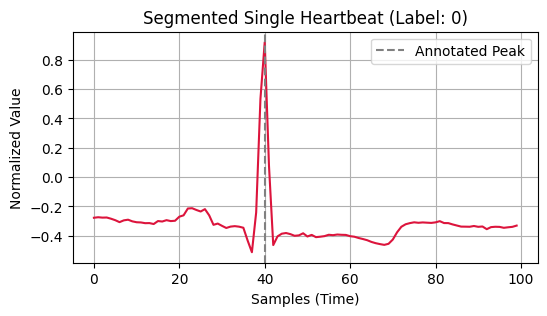


Data split complete!
Training shape: (1816, 100)
Validation shape: (455, 100)


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 1. Scale the annotation locations from 360Hz to 100Hz
# Since the time axis shrank, the peak index locations must shrink proportionally
scaled_ann_samples = np.round(annotation.sample * (target_fs / original_fs)).astype(int)
ann_symbols = annotation.symbol

X = []  # To store our 1-second heartbeat segments
y = []  # To store our labels (0 = Normal, 1 = Anomaly)

# We want a 1-second window (100 samples) around each heartbeat peak.
# We will grab 40 samples before the peak and 60 samples after the peak.
window_before = 40
window_after = 60

print("Splitting continuous wave into individual heartbeats...")

for i in range(len(scaled_ann_samples)):
    peak_index = scaled_ann_samples[i]
    symbol = ann_symbols[i]

    # Ensure the window fits completely within the signal bounds
    if peak_index - window_before >= 0 and peak_index + window_after < len(resampled_signal):
        # Slice out the 100-sample heartbeat segment
        heartbeat_segment = resampled_signal[peak_index - window_before : peak_index + window_after]

        # Categorize the beat based on MIT-BIH standard symbols
        if symbol == 'N':  # 'N' stands for Normal heartbeat
            X.append(heartbeat_segment)
            y.append(0)
        elif symbol in ['V', 'A', 'E', 'F']:  # Common arrhythmia/abnormal beat symbols
            X.append(heartbeat_segment)
            y.append(1)

# Convert to NumPy arrays for Machine Learning processing
X = np.array(X)
y = np.array(y)

print(f"Total processed heartbeats extracted: {len(X)}")
print(f"Normal beats (Class 0): {np.sum(y == 0)}")
print(f"Abnormal/Arrhythmia beats (Class 1): {np.sum(y == 1)}")

# --- Verify: Plot a single segmented heartbeat ---
plt.figure(figsize=(6, 3))
plt.plot(X[0], color='crimson')
# The R-peak is located exactly at index 40 because of our window_before setting
plt.axvline(x=40, color='gray', linestyle='--', label='Annotated Peak')
plt.title(f"Segmented Single Heartbeat (Label: {y[0]})")
plt.xlabel("Samples (Time)")
plt.ylabel("Normalized Value")
plt.legend()
plt.grid(True)
plt.show()

# 2. Split the data into Training (80%) and Validation (20%) sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nData split complete!")
print(f"Training shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")

In [10]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# 1. Convert NumPy arrays to PyTorch Tensors and add the 1-channel dimension
X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1) # Shape becomes [Samples, 1, 100]
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_val_t = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1)    # Shape becomes [Samples, 1, 100]
y_val_t = torch.tensor(y_val, dtype=torch.long)

# 2. Package them into PyTorch Datasets
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)

# 3. Create DataLoaders (Batching data into groups of 32 for smooth GPU processing)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("✅ Data successfully converted to PyTorch Tensors and batched!")
print(f"Train batches: {len(train_loader)}, Validation batches: {len(val_loader)}")

✅ Data successfully converted to PyTorch Tensors and batched!
Train batches: 57, Validation batches: 15


In [11]:
import torch.nn as nn
import torch.optim as optim

# 1. Define the Neural Network Structural Layers
class ECGNet(nn.Module):
    def __init__(self):
        super(ECGNet, self).__init__()
        # Convolutional Layer 1: Extracts micro-features (peaks, slopes)
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=2)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2) # Compresses signal length from 100 to 50

        # Convolutional Layer 2: Combines micro-features into complex wave shapes
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=2)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2) # Compresses signal length from 50 to 25

        # Dense Decision Layers
        self.fc1 = nn.Linear(32 * 25, 64)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(64, 2) # 2 Outputs: [Class 0 (Normal), Class 1 (Anomaly)]

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(x.size(0), -1) # Flatten 2D features into a 1D vector
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

# 2. Initialize Model, Loss Function, and Optimizer
model = ECGNet().cuda() # Send model straight to the Nvidia T4 GPU
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. The Live Training and Validation Loop
epochs = 15
print("🚀 Training initiated on T4 GPU...\n")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.cuda(), labels.cuda() # Push batch to GPU

        optimizer.zero_grad()   # Reset gradients
        outputs = model(inputs) # Forward pass: Predict
        loss = criterion(outputs, labels) # Calculate error
        loss.backward()         # Backward pass: Calculate adjustments
        optimizer.step()        # Update weights

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)

    # Run a quick check on validation data to see how accurate it is
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.cuda(), labels.cuda()
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = (correct / total) * 100
    print(f"Epoch {epoch+1:02d}/{epochs} -> Training Loss: {epoch_loss:.4f} | Validation Accuracy: {val_acc:.2f}%")

# 4. Save the trained weight file
torch.save(model.state_dict(), 'ecg_model_100hz.pt')
print("\n🎉 Done! The trained brain is saved as 'ecg_model_100hz.pt'.")

🚀 Training initiated on T4 GPU...

Epoch 01/15 -> Training Loss: 0.1691 | Validation Accuracy: 98.46%
Epoch 02/15 -> Training Loss: 0.0785 | Validation Accuracy: 98.46%
Epoch 03/15 -> Training Loss: 0.0798 | Validation Accuracy: 98.46%
Epoch 04/15 -> Training Loss: 0.0788 | Validation Accuracy: 98.46%
Epoch 05/15 -> Training Loss: 0.0794 | Validation Accuracy: 98.46%
Epoch 06/15 -> Training Loss: 0.0779 | Validation Accuracy: 98.46%
Epoch 07/15 -> Training Loss: 0.0776 | Validation Accuracy: 98.46%
Epoch 08/15 -> Training Loss: 0.0788 | Validation Accuracy: 98.46%
Epoch 09/15 -> Training Loss: 0.0781 | Validation Accuracy: 98.46%
Epoch 10/15 -> Training Loss: 0.0768 | Validation Accuracy: 98.46%
Epoch 11/15 -> Training Loss: 0.0732 | Validation Accuracy: 98.46%
Epoch 12/15 -> Training Loss: 0.0705 | Validation Accuracy: 98.46%
Epoch 13/15 -> Training Loss: 0.0676 | Validation Accuracy: 98.46%
Epoch 14/15 -> Training Loss: 0.0544 | Validation Accuracy: 98.46%
Epoch 15/15 -> Training Los